RMSE: 0.020958118442356753
R^2: 0.9923425643969708


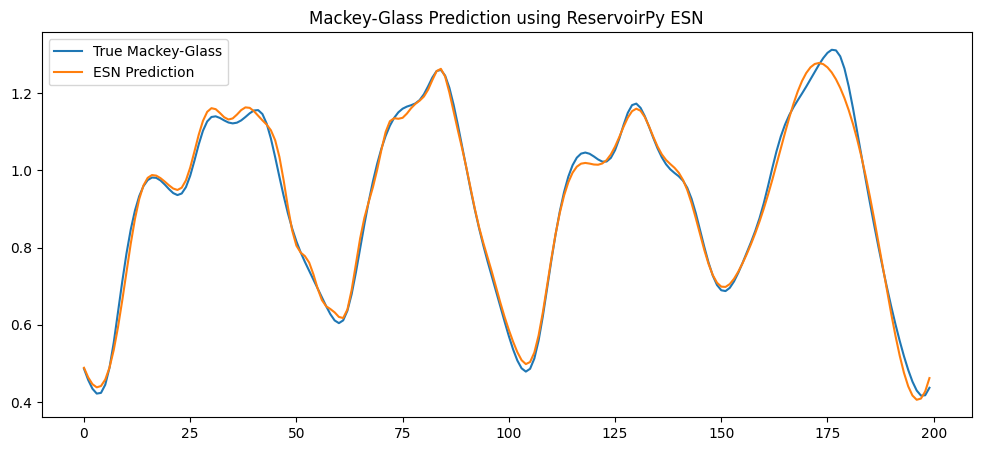

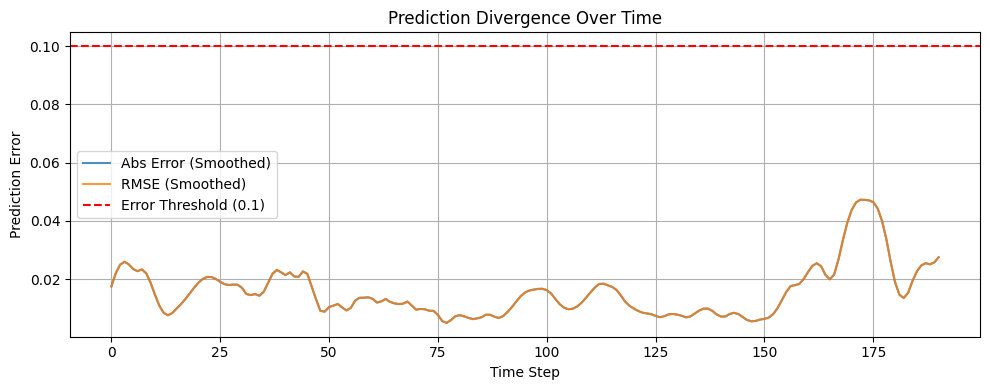

No sustained divergence above threshold 0.1 for 10 steps detected.

F-statistic: 12764.8142
P-value: 1.1102e-16
The model's predictions are statistically significant (p < 0.05).

Total runtime: 36.78 seconds


In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
#!pip install reservoirpy #(Uncomment on Google Colab)
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from scipy.stats import f

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Parameters ---
t_max = 275
delta_t = 1
train_ics_left = np.linspace(0, 1.19, 20)
train_ics_right = np.linspace(1.21, 3, 20)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data ---
X_list, y_list = [], []
for ic in train_ics:
    x = mackey_glass(t_max=t_max, x0=ic)
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Generate test data ---
x_test = mackey_glass(t_max=275, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare numpy arrays for ReservoirPy ---
X_rpy = X_scaled.reshape(len(train_ics), t_max, 2)
y_rpy = y.reshape(len(train_ics), t_max, 1)
X_test_rpy = X_test_scaled
y_test_rpy = y_test

# --- Reservoir ---
start_time = time.time()
rpy.verbosity(0)
rpy.set_seed(42)

reservoir1 = Reservoir(2000, lr=0.5, sr=0.9)
reservoir2 = Reservoir(2000, lr=0.5, sr=0.9)
readout = Ridge(ridge=1e-7)
esn_model = reservoir1 >> reservoir2 >> readout
esn_model.fit(X_rpy, y_rpy)

y_pred = esn_model.run(X_test_rpy)

washout = 75

# Divergence
errors = np.abs(y_pred[washout:, 0] - y_test_rpy[washout:])            # abs error
rmse_window = np.sqrt((y_pred[washout:, 0] - y_test_rpy[washout:])**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

rmse = np.sqrt(mean_squared_error(y_test_rpy[washout:], y_pred[washout:]))
r2 = r2_score(y_test_rpy[washout:], y_pred[washout:])
print("RMSE:", rmse)
print("R^2:", r2)

plt.figure(figsize=(12, 5))
plt.plot(y_test_rpy[washout:], label='True Mackey-Glass')
plt.plot(y_pred[washout:], label='ESN Prediction')
plt.legend()
plt.title('Mackey-Glass Prediction using ReservoirPy ESN')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
sustain_steps = 10
above_thresh = smoothed_error > threshold
sustained = np.convolve(above_thresh.astype(int), np.ones(sustain_steps, dtype=int), mode='valid') >= sustain_steps

if np.any(sustained):
    divergence_time = np.argmax(sustained) + sustain_steps - 1
    print(f"Prediction horizon at threshold {threshold} sustained for {sustain_steps} steps: {divergence_time} steps")
else:
    print(f"No sustained divergence above threshold {threshold} for {sustain_steps} steps detected.")

# --- F-test calculation ---
n = len(y_test_rpy[washout:])  # Number of samples after washout
k = X_test_rpy.shape[1]        # Number of input features (2 in this case: ic and t)

F = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f.cdf(F, k, n - k - 1)

print(f"\nF-statistic: {F:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("The model's predictions are statistically significant (p < 0.05).")
else:
    print("The model's predictions are NOT statistically significant (p ≥ 0.05).")

end_time = time.time()
print(f"\nTotal runtime: {end_time - start_time:.2f} seconds")